In [1]:
import pandas as pd
from google.colab import files

file_upload = files.upload()


Saving students.csv to students.csv


In [32]:
#task1
df = pd.read_csv("students.csv")
print(df.head())              # 1st 5 rows
print(df.shape)        # shape of dataframe
print(df.dtypes)       # datatypes of each column
print(df.describe().round(2))     # summary stats using describe
print(df['passed'].value_counts())      # count passed/failed students(1 = pass, 0 = fail)
subject_cols = ['math', 'science', 'english', 'history', 'pe']
print("Average marks for passed students\n", df[df['passed'] == 1][subject_cols].mean().round(2))  #average for passed students
print("Average marks for failed students\n", df[df['passed'] == 0][subject_cols].mean().round(2))  #average for failed students
df["avg_score"] = df[subject_cols].mean(axis=1)        #add average column
top_student = df.loc[df["avg_score"].idxmax()]            #find top student
print("top student", top_student)

      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  
(15, 9)
name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object
        math  science  english  history     pe  attendance_pct  \
count  15.00    15.00    15.00  

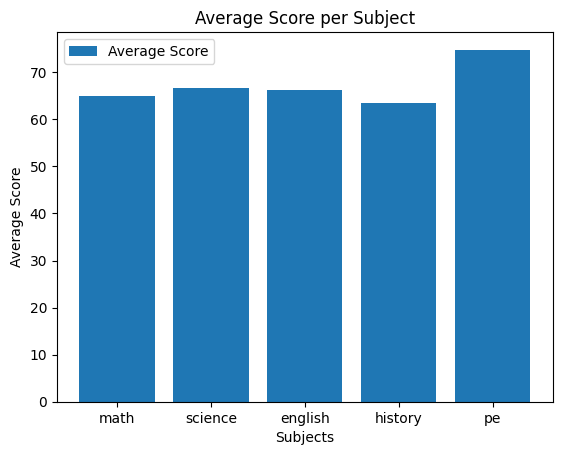

In [34]:
#task2 bar chart
import matplotlib.pyplot as plt

subjects = ["math", "science", "english", "history", "pe"]
avg_scores = df[subjects].mean()

plt.figure()
plt.bar(subjects, avg_scores)

plt.title("Average Score per Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Score")
plt.legend(["Average Score"])

plt.savefig("plot1_bar.png")
plt.show()

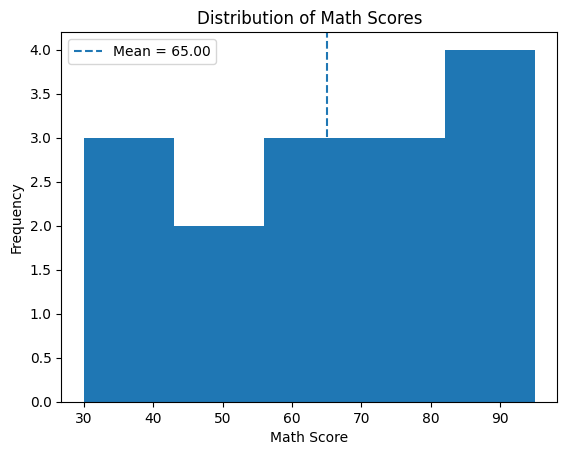

In [35]:
#histogram
plt.figure()

plt.hist(df["math"], bins=5)

mean_math = df["math"].mean()
plt.axvline(mean_math, linestyle='dashed')

plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Frequency")

plt.legend([f"Mean = {mean_math:.2f}"])

plt.savefig("plot2_hist.png")
plt.show()

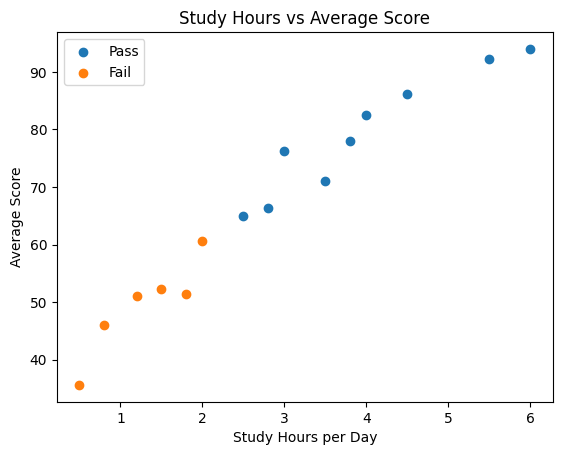

In [36]:
#scatter plot
pass_df = df[df["passed"] == 1]
fail_df = df[df["passed"] == 0]

plt.scatter(pass_df["study_hours_per_day"], pass_df["avg_score"], label="Pass")
plt.scatter(fail_df["study_hours_per_day"], fail_df["avg_score"], label="Fail")

plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")

plt.legend()

plt.savefig("plot3_scatter.png")
plt.show()

/tmp/ipykernel_7651/1413331411.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_attendance, fail_attendance], labels=["Pass", "Fail"])


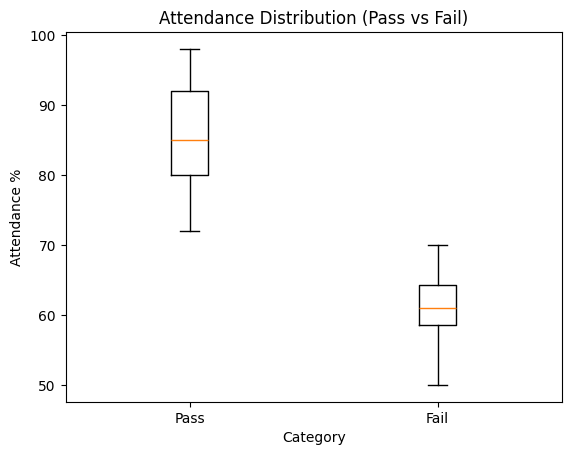

In [37]:
#Box plot
plt.figure()

pass_attendance = df[df["passed"] == 1]["attendance_pct"]
fail_attendance = df[df["passed"] == 0]["attendance_pct"]

plt.boxplot([pass_attendance, fail_attendance], labels=["Pass", "Fail"])

plt.title("Attendance Distribution (Pass vs Fail)")
plt.xlabel("Category")
plt.ylabel("Attendance %")

plt.savefig("plot4_box.png")
plt.show()

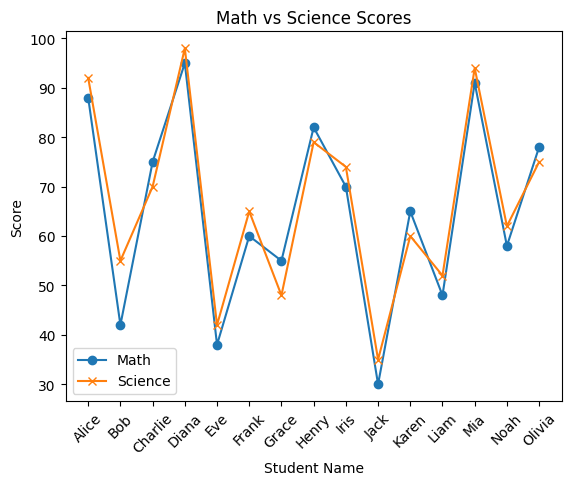

In [38]:
#line plot
plt.figure()

plt.plot(df["name"], df["math"], marker='o', label="Math")
plt.plot(df["name"], df["science"], marker='x', label="Science")

plt.title("Math vs Science Scores")
plt.xlabel("Student Name")
plt.ylabel("Score")

plt.xticks(rotation=45)

plt.legend()

plt.savefig("plot5_line.png")
plt.show()

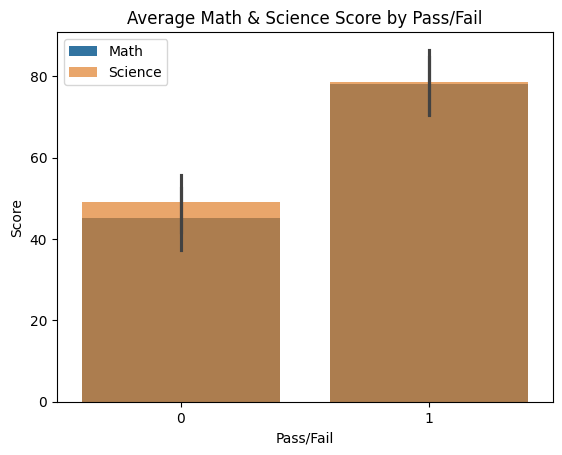

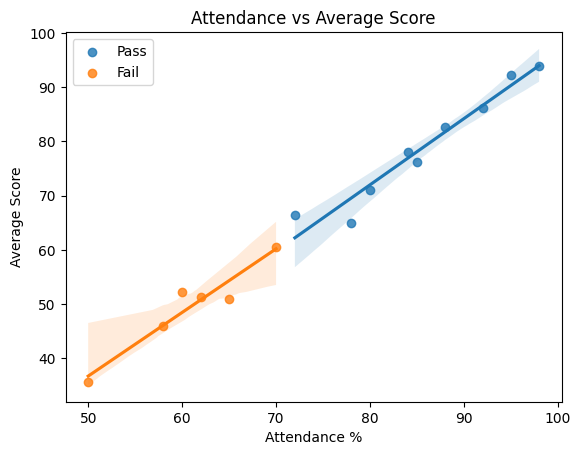

In [39]:
#task3
import seaborn as sns
import matplotlib.pyplot as plt

# Bar chart
plt.figure()

sns.barplot(data=df, x="passed", y="math", label="Math")
sns.barplot(data=df, x="passed", y="science", label="Science", alpha=0.7)

plt.title("Average Math & Science Score by Pass or Fail")
plt.xlabel("Pass/Fail")
plt.ylabel("Score")
plt.legend()

plt.savefig("seaborn_bar.png")
plt.show()

# Scatter + Regression Plot
plt.figure()

# Pass students
sns.regplot(
    data=df[df["passed"] == 1],
    x="attendance_pct",
    y="avg_score",
    label="Pass"
)

# Fail students
sns.regplot(
    data=df[df["passed"] == 0],
    x="attendance_pct",
    y="avg_score",
    label="Fail"
)

plt.title("Attendance vs Average Score")
plt.xlabel("Attendance %")
plt.ylabel("Average Score")
plt.legend()

plt.savefig("seaborn_scatter.png")
plt.show()